# Titanic Survival Prediction

EDA, feature engineering и сравнение классических моделей, бустингов, нейронных сетей и ансамблей.

## 1. Подготовка окружения

Зависимости перечислены в `requirements.txt`; установка библиотек внутри ноутбука удалена.

In [68]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from catboost import Pool, cv as catboost_cv
from IPython.display import display
from lightgbm import LGBMClassifier
from scipy.sparse import issparse
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    RandomForestClassifier,
    StackingClassifier,
    VotingClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from xgboost import XGBClassifier


## 2. Загрузка и первичный анализ данных

In [69]:
train_data = pd.read_csv('../data/train.csv')
test_data = pd.read_csv('../data/test.csv')

print("Размер train:", train_data.shape)
print("Размер test:", test_data.shape)

Размер train: (891, 12)
Размер test: (418, 11)


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


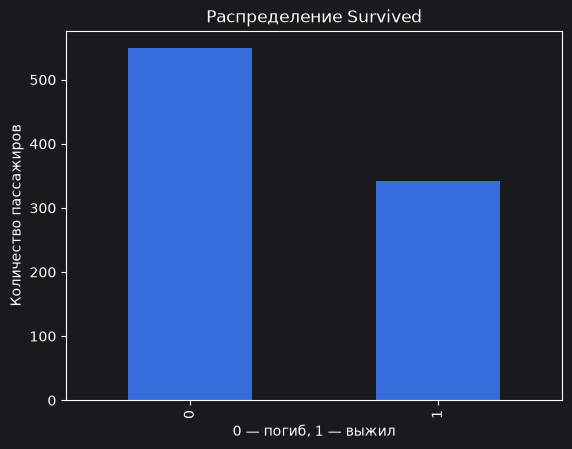

In [70]:
train_data.head()
test_data.head()
train_data.info()
train_data.describe(include="all").T

#Пропуски
missing = pd.DataFrame({
    "missing_count": train_data.isna().sum(),
    "missing_percent": train_data.isna().mean() * 100
})

missing[missing["missing_count"] > 0].sort_values(
    "missing_percent",
    ascending=False
)
#баланс целевой переменной
train_data["Survived"].value_counts()

train_data["Survived"].value_counts().sort_index().plot(kind="bar")

plt.title("Распределение Survived")
plt.xlabel("0 — погиб, 1 — выжил")
plt.ylabel("Количество пассажиров")
plt.show()

### Целевая переменная и основные категории

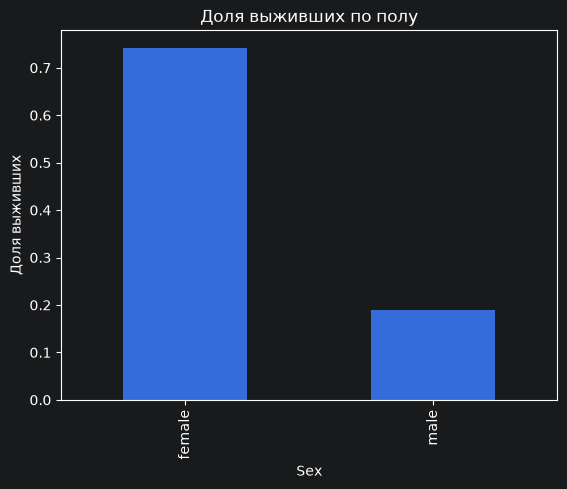

In [71]:
#Выживаемость по полу
survival_by_sex = train_data.groupby("Sex")["Survived"].mean()
survival_by_sex

survival_by_sex.plot(kind="bar")

plt.title("Доля выживших по полу")
plt.ylabel("Доля выживших")
plt.show()

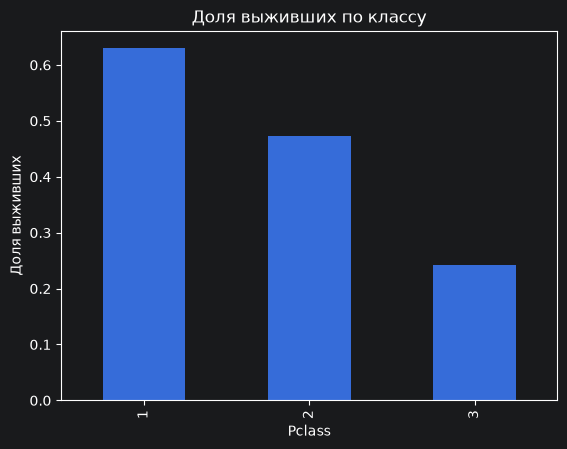

In [72]:
#Выживаемость по классу билета
survival_by_class = train_data.groupby("Pclass")["Survived"].mean()
survival_by_class
survival_by_class.plot(kind="bar")

plt.title("Доля выживших по классу")
plt.ylabel("Доля выживших")
plt.show()

### Пропущенные значения

In [73]:
missing_values = pd.DataFrame({
    "Количество пропусков": train_data.isna().sum(),
    "Процент пропусков": train_data.isna().mean() * 100
})

missing_values = missing_values[
    missing_values["Количество пропусков"] > 0
].sort_values("Процент пропусков", ascending=False)

missing_values

,Количество пропусков,Процент пропусков
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467


### Числовые признаки

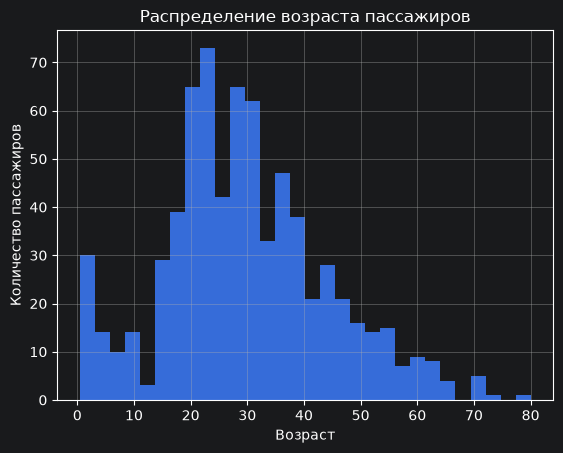

In [74]:
train_data["Age"].describe()
train_data["Age"].hist(bins=30)

plt.title("Распределение возраста пассажиров")
plt.xlabel("Возраст")
plt.ylabel("Количество пассажиров")
plt.show()

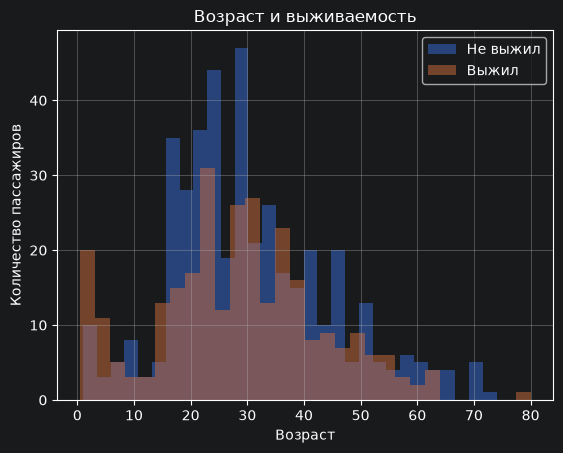

In [75]:
train_data[train_data["Survived"] == 0]["Age"].hist(
    bins=30,
    alpha=0.5,
    label="Не выжил"
)

train_data[train_data["Survived"] == 1]["Age"].hist(
    bins=30,
    alpha=0.5,
    label="Выжил"
)

plt.title("Возраст и выживаемость")
plt.xlabel("Возраст")
plt.ylabel("Количество пассажиров")
plt.legend()
plt.show()

**Вывод:** возраст полезен совместно с другими признаками, но сам по себе разделяет классы слабее пола и класса билета.

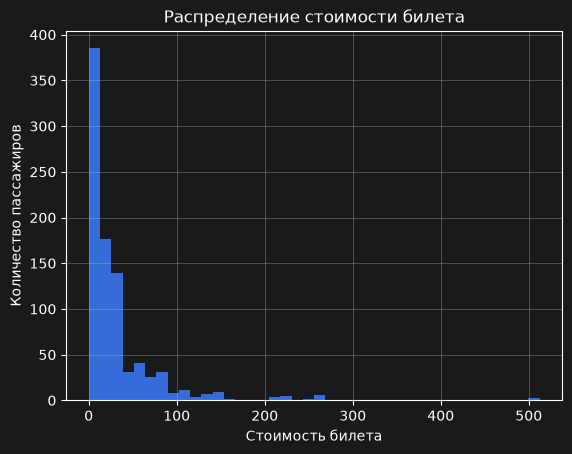

In [76]:
train_data["Fare"].describe()
train_data["Fare"].hist(bins=40)

plt.title("Распределение стоимости билета")
plt.xlabel("Стоимость билета")
plt.ylabel("Количество пассажиров")
plt.show()

### Порт посадки и класс билета

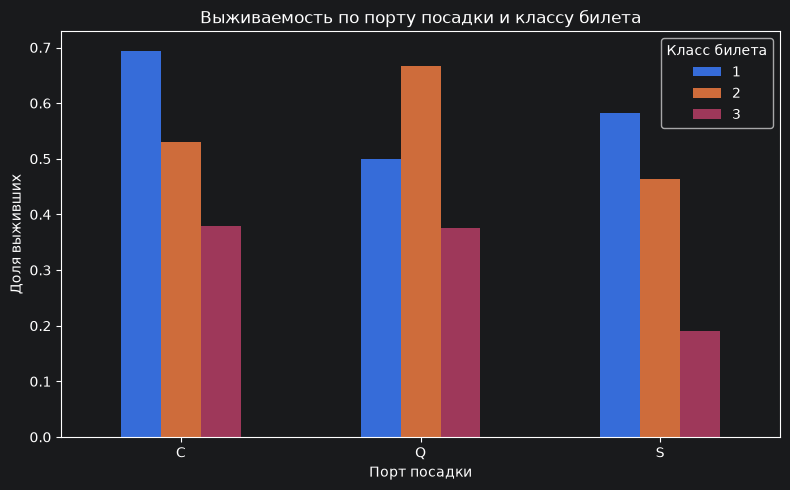

In [77]:
survival_port_class = train_data.groupby(
    ["Embarked", "Pclass"]
)["Survived"].mean().unstack()

survival_port_class.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Выживаемость по порту посадки и классу билета")
plt.xlabel("Порт посадки")
plt.ylabel("Доля выживших")
plt.xticks(rotation=0)
plt.legend(title="Класс билета")
plt.tight_layout()
plt.show()

## 3. Feature Engineering

Создаём `FamilySize`, `IsAlone`, `CabinKnown` и `TitleGrouped`.

            count      mean
FamilySize                 
1             537  0.303538
2             161  0.552795
3             102  0.578431
4              29  0.724138
5              15  0.200000
6              22  0.136364
7              12  0.333333
8               6  0.000000
11              7  0.000000


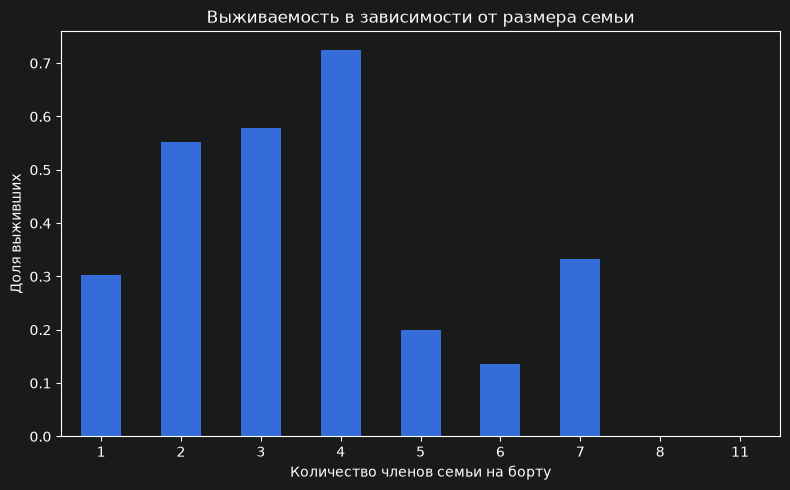

In [78]:
train_data["FamilySize"] = (
    train_data["SibSp"]
    + train_data["Parch"]
    + 1
)

survival_by_family = train_data.groupby(
    "FamilySize"
)["Survived"].agg(["count", "mean"])

print(survival_by_family)

survival_by_family["mean"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Выживаемость в зависимости от размера семьи")
plt.xlabel("Количество членов семьи на борту")
plt.ylabel("Доля выживших")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

         count      mean
IsAlone                 
0          354  0.505650
1          537  0.303538


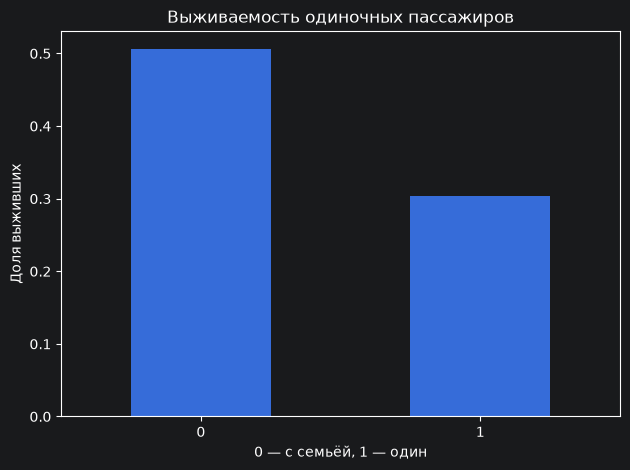

In [79]:
train_data["IsAlone"] = (train_data["FamilySize"] == 1).astype(int)

survival_by_alone = train_data.groupby("IsAlone")["Survived"].agg(["count", "mean"])
print(survival_by_alone)

survival_by_alone["mean"].plot(kind="bar")
plt.title("Выживаемость одиночных пассажиров")
plt.xlabel("0 — с семьёй, 1 — один")
plt.ylabel("Доля выживших")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

            count      mean
CabinKnown                 
0             687  0.299854
1             204  0.666667


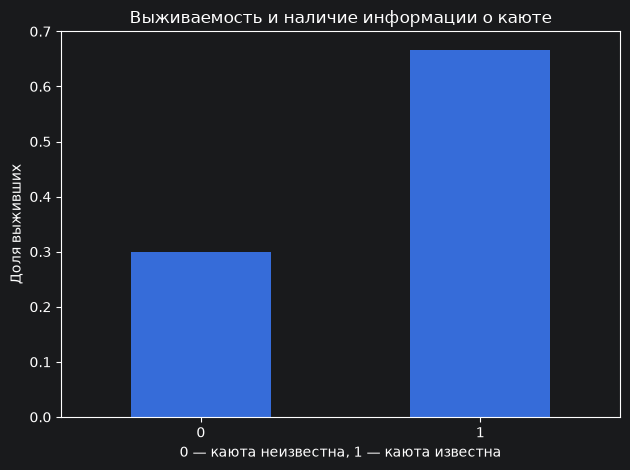

In [80]:
train_data["CabinKnown"] = train_data["Cabin"].notna().astype(int)

survival_by_cabin = train_data.groupby("CabinKnown")["Survived"].agg(["count", "mean"])
print(survival_by_cabin)

survival_by_cabin["mean"].plot(kind="bar")
plt.title("Выживаемость и наличие информации о каюте")
plt.xlabel("0 — каюта неизвестна, 1 — каюта известна")
plt.ylabel("Доля выживших")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

              count      mean
TitleGrouped                 
Master           40  0.575000
Miss            182  0.697802
Mr              517  0.156673
Mrs             125  0.792000
Rare             27  0.444444


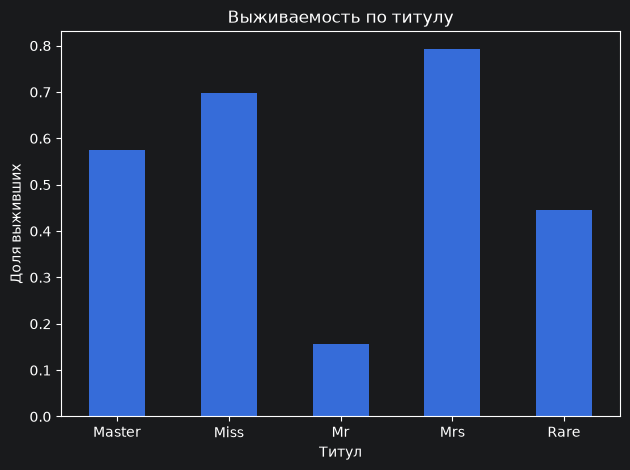

In [81]:
train_data["Title"] = train_data["Name"].str.extract(r",\s*([^.]*)\.")

title_stats = train_data.groupby("Title")["Survived"].agg(["count", "mean"])
title_stats.sort_values("count", ascending=False)
common_titles = ["Mr", "Miss", "Mrs", "Master"]

train_data["TitleGrouped"] = train_data["Title"].where(
    train_data["Title"].isin(common_titles),
    "Rare"
)

survival_by_title = train_data.groupby("TitleGrouped")["Survived"].agg(["count", "mean"])
print(survival_by_title)

survival_by_title["mean"].plot(kind="bar")
plt.title("Выживаемость по титулу")
plt.xlabel("Титул")
plt.ylabel("Доля выживших")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

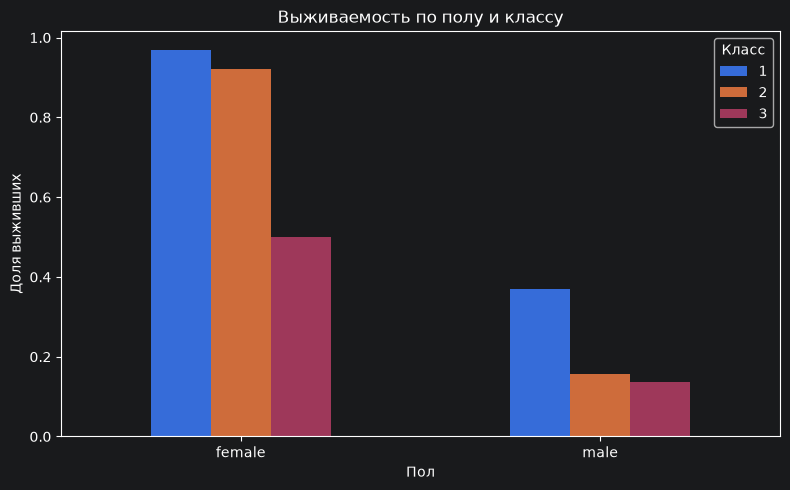

In [82]:
survival_sex_class = train_data.groupby(
    ["Sex", "Pclass"]
)["Survived"].mean().unstack()

survival_sex_class.plot(kind="bar", figsize=(8, 5))

plt.title("Выживаемость по полу и классу")
plt.xlabel("Пол")
plt.ylabel("Доля выживших")
plt.xticks(rotation=0)
plt.legend(title="Класс")
plt.tight_layout()
plt.show()

### Корреляции

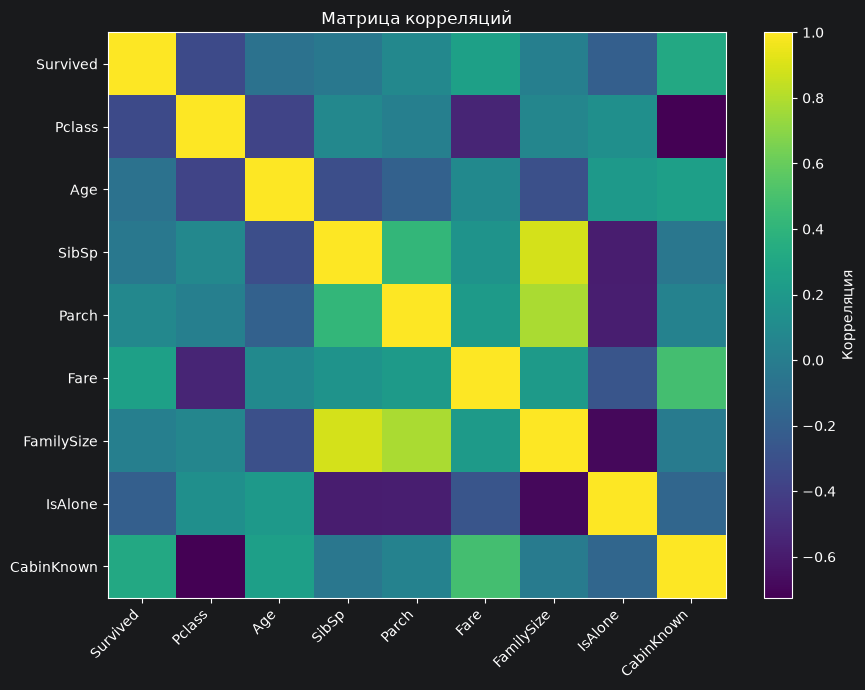

In [83]:
numeric_columns = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "IsAlone",
    "CabinKnown",
]
correlation = train_data[numeric_columns].corr()

plt.figure(figsize=(9, 7))
plt.imshow(correlation, aspect="auto")
plt.colorbar(label="Корреляция")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(correlation.index)),
    correlation.index
)

plt.title("Матрица корреляций")
plt.tight_layout()
plt.show()

**Вывод EDA:** наиболее заметные связи с выживаемостью наблюдаются у пола, класса, стоимости билета и новых семейных/каютных признаков.

## 4. Бейзлайн

Logistic Regression без новых признаков, оценка через стратифицированную 5-fold кросс-валидацию.

In [84]:
numeric_features = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
]

categorical_features = [
    "Pclass",
    "Sex",
    "Embarked",
]

features = numeric_features + categorical_features

X = train_data[features]
y = train_data["Survived"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000)),
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="accuracy",
)

print("Accuracy по фолдам:", scores)
print("Средняя accuracy:", scores.mean())
print("Стандартное отклонение:", scores.std())

Accuracy по фолдам: [0.78212291 0.80337079 0.79775281 0.78089888 0.82022472]
Средняя accuracy: 0.7968740192078337
Стандартное отклонение: 0.01456733331525481


In [85]:
baseline_score = scores.mean()

print("Baseline accuracy:", baseline_score)

Baseline accuracy: 0.7968740192078337


## 5. Модели с новыми признаками

`add_features` одинаково применяется к train и test.

In [86]:
def add_features(data):
    """Create engineered Titanic features without changing the input."""
    data = data.copy()

    data["FamilySize"] = data["SibSp"] + data["Parch"] + 1
    data["IsAlone"] = (data["FamilySize"] == 1).astype(int)
    data["CabinKnown"] = data["Cabin"].notna().astype(int)

    data["Title"] = data["Name"].str.extract(r",\s*([^.]*)\.")

    common_titles = ["Mr", "Miss", "Mrs", "Master"]

    data["TitleGrouped"] = data["Title"].where(
        data["Title"].isin(common_titles),
        "Rare",
    )

    return data

train_fe = add_features(train_data)

numeric_features_fe = [
    "Age",
    "Fare",
    "FamilySize",
    "IsAlone",
    "CabinKnown",
]

categorical_features_fe = [
    "Pclass",
    "Sex",
    "Embarked",
    "TitleGrouped",
]

features_fe = numeric_features_fe + categorical_features_fe

X_fe = train_fe[features_fe]
y = train_fe["Survived"]

In [87]:
numeric_pipeline_fe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline_fe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor_fe = ColumnTransformer([
    ("numeric", numeric_pipeline_fe, numeric_features_fe),
    ("categorical", categorical_pipeline_fe, categorical_features_fe),
])

model_fe = Pipeline([
    ("preprocessor", preprocessor_fe),
    ("classifier", LogisticRegression(max_iter=1000)),
])

scores_fe = cross_val_score(
    model_fe,
    X_fe,
    y,
    cv=cv,
    scoring="accuracy",
)

feature_score = scores_fe.mean()

print("Accuracy по фолдам:", scores_fe)
print("Baseline:", baseline_score)
print("С новыми признаками:", feature_score)
print("Изменение:", feature_score - baseline_score)

Accuracy по фолдам: [0.84357542 0.82022472 0.81460674 0.83146067 0.83146067]
Baseline: 0.7968740192078337
С новыми признаками: 0.8282656455966354
Изменение: 0.03139162638880166


**Эффект feature engineering:** средняя accuracy Logistic Regression выросла примерно с `0.7969` до `0.8283`.

### KNN, Decision Tree и Random Forest

In [88]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
    ),
}

model_results = []

for model_name, classifier in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor_fe),
        ("classifier", classifier),
    ])

    model_scores = cross_val_score(
        pipeline,
        X_fe,
        y,
        cv=cv,
        scoring="accuracy",
    )

    model_results.append({
        "model": model_name,
        "accuracy_mean": model_scores.mean(),
        "accuracy_std": model_scores.std(),
    })

    print(f"{model_name}: {model_scores.mean():.4f}")

KNN: 0.8204
Decision Tree: 0.8137
Random Forest: 0.8328


In [89]:
all_results = model_results + [{
    "model": "Logistic Regression",
    "accuracy_mean": scores_fe.mean(),
    "accuracy_std": scores_fe.std(),
}]

results = (
    pd.DataFrame(all_results)
    .sort_values("accuracy_mean", ascending=False)
    .reset_index(drop=True)
)

display(results.round(4))
print(results.round(4).to_string(index=False))

,model,accuracy_mean,accuracy_std
0,Random Forest,0.8328,0.0099
1,Logistic Regression,0.8283,0.0101
2,KNN,0.8204,0.0371
3,Decision Tree,0.8137,0.0222


              model  accuracy_mean  accuracy_std
      Random Forest         0.8328        0.0099
Logistic Regression         0.8283        0.0101
                KNN         0.8204        0.0371
      Decision Tree         0.8137        0.0222


## 6. Градиентный бустинг

Сравниваются CatBoost, LightGBM и XGBoost.

In [90]:
cat_features = ["Pclass", "Sex", "Embarked", "TitleGrouped"]

X_cat = train_fe[features_fe].copy()
X_cat[cat_features] = X_cat[cat_features].fillna("Unknown").astype(str)

data_pool = Pool(
    data=X_cat,
    label=y,
    cat_features=cat_features,
)

params = {
    "iterations": 500,
    "depth": 5,
    "learning_rate": 0.03,
    "l2_leaf_reg": 5,
    "loss_function": "Logloss",
    "eval_metric": "Accuracy",
    "random_seed": 42,
    "verbose": False,
    "allow_writing_files": False,
}

catboost_results = catboost_cv(
    pool=data_pool,
    params=params,
    fold_count=5,
    stratified=True,
    shuffle=True,
    partition_random_seed=42,
    verbose=False,
)

best_iteration = catboost_results["test-Accuracy-mean"].idxmax()

catboost_mean = catboost_results.loc[
    best_iteration, "test-Accuracy-mean"
]

catboost_std = catboost_results.loc[
    best_iteration, "test-Accuracy-std"
]

print("Лучшая итерация:", best_iteration + 1)
print("CatBoost mean:", catboost_mean)
print("CatBoost std:", catboost_std)

Training on fold [0/5]

bestTest = 0.8659217877
bestIteration = 78

Training on fold [1/5]

bestTest = 0.8100558659
bestIteration = 495

Training on fold [2/5]

bestTest = 0.8202247191
bestIteration = 460

Training on fold [3/5]

bestTest = 0.8764044944
bestIteration = 90

Training on fold [4/5]

bestTest = 0.8305084746
bestIteration = 86

Лучшая итерация: 94
CatBoost mean: 0.8316593416453086
CatBoost std: 0.03399216226551137


In [91]:
cv_splitter = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

lightgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.03,
    num_leaves=15,
    max_depth=5,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
)

lightgbm_pipeline = Pipeline([
    ("preprocessor", preprocessor_fe),
    ("classifier", lightgbm_model),
])

lightgbm_scores = cross_val_score(
    lightgbm_pipeline,
    X_fe,
    y,
    cv=cv_splitter,
    scoring="accuracy",
)

print("LightGBM по фолдам:", lightgbm_scores)
print("LightGBM mean:", lightgbm_scores.mean())
print("LightGBM std:", lightgbm_scores.std())

LightGBM по фолдам: [0.8547486  0.87640449 0.79775281 0.83707865 0.81460674]
LightGBM mean: 0.8361182599962337
LightGBM std: 0.02794868863690614


In [92]:
xgboost_model = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)

xgboost_pipeline = Pipeline([
    ("preprocessor", preprocessor_fe),
    ("classifier", xgboost_model),
])

xgboost_scores = cross_val_score(
    xgboost_pipeline,
    X_fe,
    y,
    cv=cv_splitter,
    scoring="accuracy",
)

print("XGBoost по фолдам:", xgboost_scores)
print("XGBoost mean:", xgboost_scores.mean())
print("XGBoost std:", xgboost_scores.std())

XGBoost по фолдам: [0.8603352  0.87640449 0.78089888 0.84269663 0.83146067]
XGBoost mean: 0.838359173937606
XGBoost std: 0.032552973882158304


### Сводная таблица моделей

In [93]:
boosting_results = [
    {
        "model": "Logistic Regression",
        "accuracy_mean": scores_fe.mean(),
        "accuracy_std": scores_fe.std(),
    },
    {
        "model": "CatBoost",
        "accuracy_mean": catboost_mean,
        "accuracy_std": catboost_std,
    },
    {
        "model": "LightGBM",
        "accuracy_mean": lightgbm_scores.mean(),
        "accuracy_std": lightgbm_scores.std(),
    },
    {
        "model": "XGBoost",
        "accuracy_mean": xgboost_scores.mean(),
        "accuracy_std": xgboost_scores.std(),
    },
]

results = pd.concat(
    [
        pd.DataFrame(model_results),   # KNN, дерево, Random Forest
        pd.DataFrame(boosting_results),
    ],
    ignore_index=True,
)

results = (
    results
    .drop_duplicates(subset="model", keep="last")
    .sort_values("accuracy_mean", ascending=False)
    .reset_index(drop=True)
)

display(results.round(4))

output_path = Path("../results/metrics.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)
results.to_csv(output_path, index=False)

print("Результаты сохранены:", output_path.resolve())

,model,accuracy_mean,accuracy_std
0,XGBoost,0.8384,0.0326
1,LightGBM,0.8361,0.0279
2,Random Forest,0.8328,0.0099
3,CatBoost,0.8317,0.0340
4,Logistic Regression,0.8283,0.0101
5,KNN,0.8204,0.0371
6,Decision Tree,0.8137,0.0222


Результаты сохранены: C:\PythonProjects\titanic\results\metrics.csv


**Промежуточный вывод:** среди одиночных моделей и бустингов лучший средний результат показал XGBoost, а Random Forest был наиболее стабильным.

## 7. Deep Neural Network

Сначала архитектуры быстро сравниваются на одном validation split, затем лучшие варианты проверяются на пяти фолдах.

In [94]:
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

PyTorch: 2.13.0+cpu
CUDA: False


### Подготовка данных для DNN

In [95]:
X_train_raw, X_validation_raw, y_train_raw, y_validation_raw = (
    train_test_split(
        X_fe,
        y,
        test_size=0.2,
        stratify=y,
        random_state=42,
    )
)

dnn_preprocessor = clone(preprocessor_fe)

X_train_dnn = dnn_preprocessor.fit_transform(X_train_raw)
X_validation_dnn = dnn_preprocessor.transform(X_validation_raw)

if issparse(X_train_dnn):
    X_train_dnn = X_train_dnn.toarray()
    X_validation_dnn = X_validation_dnn.toarray()

X_train_tensor = torch.tensor(
    X_train_dnn,
    dtype=torch.float32,
)

X_validation_tensor = torch.tensor(
    X_validation_dnn,
    dtype=torch.float32,
)

y_train_tensor = torch.tensor(
    y_train_raw.to_numpy(),
    dtype=torch.float32,
).reshape(-1, 1)

y_validation_tensor = torch.tensor(
    y_validation_raw.to_numpy(),
    dtype=torch.float32,
).reshape(-1, 1)

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
)

print("Количество входных признаков:", X_train_tensor.shape[1])

Количество входных признаков: 18


### DNN-1: `input → 64 → ReLU → output`

In [96]:
class SimpleMLP(nn.Module):
    """Two-layer MLP used as a neural-network baseline."""
    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.network(x)

In [97]:
torch.manual_seed(42)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = SimpleMLP(
    input_size=X_train_tensor.shape[1]
).to(device)

loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
)

n_epochs = 100

for epoch in range(n_epochs):
    model.train()

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = loss_fn(logits, y_batch)

        loss.backward()
        optimizer.step()

In [98]:
model.eval()

with torch.no_grad():
    validation_logits = model(
        X_validation_tensor.to(device)
    )

    validation_probabilities = torch.sigmoid(
        validation_logits
    )

    validation_predictions = (
        validation_probabilities >= 0.5
    ).float()

dnn_baseline_accuracy = (
    validation_predictions.cpu()
    == y_validation_tensor
).float().mean().item()

print("DNN-1 validation accuracy:", dnn_baseline_accuracy)

DNN-1 validation accuracy: 0.8100558519363403


### DNN-2: `input → 128 → 64 → output`

In [99]:
class DeepMLP(nn.Module):
    """MLP with two hidden layers."""
    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.network(x)

In [100]:
def train_and_evaluate(model, n_epochs=100, lr=0.001):
    """Train a model on the fixed split and return validation accuracy."""
    model = model.to(device)

    loss_fn = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
    )

    for epoch in range(n_epochs):
        model.train()

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)

            loss.backward()
            optimizer.step()

    model.eval()

    with torch.no_grad():
        logits = model(X_validation_tensor.to(device))
        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).float()

    accuracy = (
        predictions.cpu() == y_validation_tensor
    ).float().mean().item()

    return accuracy

In [101]:
torch.manual_seed(42)

dnn_2_model = DeepMLP(
    input_size=X_train_tensor.shape[1]
)

dnn_2_accuracy = train_and_evaluate(
    model=dnn_2_model,
    n_epochs=100,
    lr=0.001,
)

print("DNN-1 accuracy:", dnn_baseline_accuracy)
print("DNN-2 accuracy:", dnn_2_accuracy)

DNN-1 accuracy: 0.8100558519363403
DNN-2 accuracy: 0.7821229100227356


In [102]:
dnn_results = pd.DataFrame([
    {
        "model": "DNN-1",
        "architecture": "64",
        "accuracy": dnn_baseline_accuracy,
    },
    {
        "model": "DNN-2",
        "architecture": "128-64",
        "accuracy": dnn_2_accuracy,
    },
])

display(dnn_results.round(4))

,model,architecture,accuracy
0,DNN-1,64,0.8101
1,DNN-2,128-64,0.7821


### DNN-3: BatchNorm и Dropout

In [103]:
class RegularizedMLP(nn.Module):
    """MLP with BatchNorm and configurable Dropout."""
    def __init__(self, input_size, dropout=0.3):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.network(x)

In [104]:
torch.manual_seed(42)

dnn_3_model = RegularizedMLP(
    input_size=X_train_tensor.shape[1],
    dropout=0.3,
)

dnn_3_accuracy = train_and_evaluate(
    model=dnn_3_model,
    n_epochs=100,
    lr=0.001,
)

print("DNN-1 accuracy:", dnn_baseline_accuracy)
print("DNN-2 accuracy:", dnn_2_accuracy)
print("DNN-3 accuracy:", dnn_3_accuracy)

DNN-1 accuracy: 0.8100558519363403
DNN-2 accuracy: 0.7821229100227356
DNN-3 accuracy: 0.7988826632499695


In [105]:
dnn_results = pd.DataFrame([
    {
        "model": "DNN-1",
        "architecture": "64",
        "batchnorm": False,
        "dropout": 0.0,
        "accuracy": dnn_baseline_accuracy,
    },
    {
        "model": "DNN-2",
        "architecture": "128-64",
        "batchnorm": False,
        "dropout": 0.0,
        "accuracy": dnn_2_accuracy,
    },
    {
        "model": "DNN-3",
        "architecture": "128-64",
        "batchnorm": True,
        "dropout": 0.3,
        "accuracy": dnn_3_accuracy,
    },
])

display(dnn_results.round(4))

,model,architecture,batchnorm,dropout,accuracy
0,DNN-1,64,False,0.0,0.8101
1,DNN-2,128-64,False,0.0,0.7821
2,DNN-3,128-64,True,0.3,0.7989


### DNN-4: CosineAnnealingLR

In [106]:
def train_with_scheduler(
    model,
    n_epochs=100,
    lr=0.001,
    optimizer_name="adam",
):
    """Train with a selectable optimizer and cosine scheduler."""
    model = model.to(device)
    loss_fn = nn.BCEWithLogitsLoss()

    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=lr,
        )
    elif optimizer_name == "sgd":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=0.9,
        )
    else:
        raise ValueError("Неизвестный optimizer")

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=n_epochs,
        eta_min=0.00001,
    )

    for epoch in range(n_epochs):
        model.train()

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)

            loss.backward()
            optimizer.step()

        scheduler.step()

    model.eval()

    with torch.no_grad():
        logits = model(X_validation_tensor.to(device))
        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).float()

    accuracy = (
        predictions.cpu() == y_validation_tensor
    ).float().mean().item()

    return accuracy

In [107]:
torch.manual_seed(42)

dnn_4_model = RegularizedMLP(
    input_size=X_train_tensor.shape[1],
    dropout=0.3,
)

dnn_4_accuracy = train_with_scheduler(
    model=dnn_4_model,
    n_epochs=100,
    lr=0.001,
    optimizer_name="adam",
)

print("DNN-3 accuracy:", dnn_3_accuracy)
print("DNN-4 accuracy:", dnn_4_accuracy)

DNN-3 accuracy: 0.7988826632499695
DNN-4 accuracy: 0.8156424760818481


In [108]:
dnn_results = pd.concat([
    dnn_results,
    pd.DataFrame([{
        "model": "DNN-4",
        "architecture": "128-64",
        "batchnorm": True,
        "dropout": 0.3,
        "optimizer": "Adam",
        "scheduler": "CosineAnnealingLR",
        "accuracy": dnn_4_accuracy,
    }]),
], ignore_index=True)

dnn_results = (
    dnn_results
    .drop_duplicates(subset="model", keep="last")
    .sort_values("accuracy", ascending=False)
    .reset_index(drop=True)
)

display(dnn_results.round(4))

,model,architecture,batchnorm,dropout,accuracy,optimizer,scheduler
0,DNN-4,128-64,True,0.3,0.8156,Adam,CosineAnnealingLR
1,DNN-1,64,False,0.0,0.8101,NaN,NaN
2,DNN-3,128-64,True,0.3,0.7989,NaN,NaN
3,DNN-2,128-64,False,0.0,0.7821,NaN,NaN


### DNN-5: Adam и SGD

In [109]:
torch.manual_seed(42)

dnn_5_model = RegularizedMLP(
    input_size=X_train_tensor.shape[1],
    dropout=0.3,
)

dnn_5_accuracy = train_with_scheduler(
    model=dnn_5_model,
    n_epochs=100,
    lr=0.01,
    optimizer_name="sgd",
)

print("DNN-4 Adam accuracy:", dnn_4_accuracy)
print("DNN-5 SGD accuracy:", dnn_5_accuracy)

DNN-4 Adam accuracy: 0.8156424760818481
DNN-5 SGD accuracy: 0.8156424760818481


In [110]:
dnn_results = pd.concat([
    dnn_results,
    pd.DataFrame([{
        "model": "DNN-5",
        "architecture": "128-64",
        "batchnorm": True,
        "dropout": 0.3,
        "optimizer": "SGD",
        "scheduler": "CosineAnnealingLR",
        "accuracy": dnn_5_accuracy,
    }]),
], ignore_index=True)

dnn_results = (
    dnn_results
    .drop_duplicates(subset="model", keep="last")
    .sort_values("accuracy", ascending=False)
    .reset_index(drop=True)
)

display(dnn_results.round(4))

,model,architecture,batchnorm,dropout,accuracy,optimizer,scheduler
0,DNN-4,128-64,True,0.3,0.8156,Adam,CosineAnnealingLR
1,DNN-5,128-64,True,0.3,0.8156,SGD,CosineAnnealingLR
2,DNN-1,64,False,0.0,0.8101,NaN,NaN
3,DNN-3,128-64,True,0.3,0.7989,NaN,NaN
4,DNN-2,128-64,False,0.0,0.7821,NaN,NaN


### Разные значения Dropout

In [111]:
dropout_experiments = []

for model_name, dropout_value in [
    ("DNN-6", 0.1),
    ("DNN-7", 0.5),
]:
    torch.manual_seed(42)

    experiment_model = RegularizedMLP(
        input_size=X_train_tensor.shape[1],
        dropout=dropout_value,
    )

    experiment_accuracy = train_with_scheduler(
        model=experiment_model,
        n_epochs=100,
        lr=0.001,
        optimizer_name="adam",
    )

    dropout_experiments.append({
        "model": model_name,
        "architecture": "128-64",
        "batchnorm": True,
        "dropout": dropout_value,
        "optimizer": "Adam",
        "scheduler": "CosineAnnealingLR",
        "accuracy": experiment_accuracy,
    })

    print(
        f"{model_name}, dropout={dropout_value}:",
        experiment_accuracy,
    )

DNN-6, dropout=0.1: 0.7765362858772278
DNN-7, dropout=0.5: 0.826815664768219


In [112]:
dnn_results = pd.concat(
    [
        dnn_results,
        pd.DataFrame(dropout_experiments),
    ],
    ignore_index=True,
)

dnn_results = (
    dnn_results
    .drop_duplicates(subset="model", keep="last")
    .sort_values("accuracy", ascending=False)
    .reset_index(drop=True)
)

display(dnn_results.round(4))

dnn_results.to_csv(
    "../results/dnn_results.csv",
    index=False,
)

print("Результаты DNN сохранены")

,model,architecture,batchnorm,dropout,accuracy,optimizer,scheduler
0,DNN-7,128-64,True,0.5,0.8268,Adam,CosineAnnealingLR
1,DNN-5,128-64,True,0.3,0.8156,SGD,CosineAnnealingLR
2,DNN-4,128-64,True,0.3,0.8156,Adam,CosineAnnealingLR
3,DNN-1,64,False,0.0,0.8101,NaN,NaN
4,DNN-3,128-64,True,0.3,0.7989,NaN,NaN
5,DNN-2,128-64,False,0.0,0.7821,NaN,NaN
6,DNN-6,128-64,True,0.1,0.7765,Adam,CosineAnnealingLR


Результаты DNN сохранены


### Размеры слоёв и функции активации

In [113]:
def make_activation(name):
    """Return a PyTorch activation layer by name."""
    if name == "relu":
        return nn.ReLU()
    if name == "leaky_relu":
        return nn.LeakyReLU(negative_slope=0.01)
    if name == "silu":
        return nn.SiLU()

    raise ValueError("Неизвестная функция активации")

class FlexibleMLP(nn.Module):
    """Configurable MLP for architecture and activation experiments."""
    def __init__(
        self,
        input_size,
        hidden_sizes,
        activation="relu",
        dropout=0.3,
    ):
        super().__init__()

        layers = []
        previous_size = input_size

        for hidden_size in hidden_sizes:
            layers.extend([
                nn.Linear(previous_size, hidden_size),
                nn.BatchNorm1d(hidden_size),
                make_activation(activation),
                nn.Dropout(dropout),
            ])

            previous_size = hidden_size

        layers.append(nn.Linear(previous_size, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [114]:
architecture_experiments = []

experiment_configs = [
    {
        "model": "DNN-8",
        "hidden_sizes": [64, 32],
        "activation": "relu",
    },
    {
        "model": "DNN-9",
        "hidden_sizes": [256, 128],
        "activation": "relu",
    },
    {
        "model": "DNN-10",
        "hidden_sizes": [128, 64],
        "activation": "leaky_relu",
    },
    {
        "model": "DNN-11",
        "hidden_sizes": [128, 64],
        "activation": "silu",
    },
]

for config in experiment_configs:
    torch.manual_seed(42)

    experiment_model = FlexibleMLP(
        input_size=X_train_tensor.shape[1],
        hidden_sizes=config["hidden_sizes"],
        activation=config["activation"],
        dropout=0.3,
    )

    experiment_accuracy = train_with_scheduler(
        model=experiment_model,
        n_epochs=100,
        lr=0.001,
        optimizer_name="adam",
    )

    architecture = "-".join(
        map(str, config["hidden_sizes"])
    )

    architecture_experiments.append({
        "model": config["model"],
        "architecture": architecture,
        "batchnorm": True,
        "dropout": 0.3,
        "activation": config["activation"],
        "optimizer": "Adam",
        "scheduler": "CosineAnnealingLR",
        "accuracy": experiment_accuracy,
    })

    print(
        config["model"],
        architecture,
        config["activation"],
        experiment_accuracy,
    )

DNN-8 64-32 relu 0.8212290406227112
DNN-9 256-128 relu 0.7932960987091064
DNN-10 128-64 leaky_relu 0.8100558519363403
DNN-11 128-64 silu 0.826815664768219


In [115]:
dnn_results = pd.concat(
    [
        dnn_results,
        pd.DataFrame(architecture_experiments),
    ],
    ignore_index=True,
)

dnn_results = (
    dnn_results
    .drop_duplicates(subset="model", keep="last")
    .sort_values("accuracy", ascending=False)
    .reset_index(drop=True)
)

display(dnn_results.round(4))

dnn_results.to_csv(
    "../results/dnn_results.csv",
    index=False,
)

print("Результаты DNN сохранены")

,model,architecture,batchnorm,dropout,accuracy,optimizer,scheduler,activation
0,DNN-7,128-64,True,0.5,0.8268,Adam,CosineAnnealingLR,NaN
1,DNN-11,128-64,True,0.3,0.8268,Adam,CosineAnnealingLR,silu
2,DNN-8,64-32,True,0.3,0.8212,Adam,CosineAnnealingLR,relu
3,DNN-4,128-64,True,0.3,0.8156,Adam,CosineAnnealingLR,NaN
4,DNN-5,128-64,True,0.3,0.8156,SGD,CosineAnnealingLR,NaN
5,DNN-1,64,False,0.0,0.8101,NaN,NaN,NaN
6,DNN-10,128-64,True,0.3,0.8101,Adam,CosineAnnealingLR,leaky_relu
7,DNN-3,128-64,True,0.3,0.7989,NaN,NaN,NaN
8,DNN-9,256-128,True,0.3,0.7933,Adam,CosineAnnealingLR,relu
9,DNN-2,128-64,False,0.0,0.7821,NaN,NaN,NaN


Результаты DNN сохранены


### Learning rate, batch size и epochs

In [116]:
def train_with_params(
    model,
    n_epochs=100,
    lr=0.001,
    batch_size=32,
):
    """Train with configurable learning rate, batch size and epochs."""
    model = model.to(device)

    loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
    )

    loss_fn = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=n_epochs,
        eta_min=0.00001,
    )

    for epoch in range(n_epochs):
        model.train()

        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)

            loss.backward()
            optimizer.step()

        scheduler.step()

    model.eval()

    with torch.no_grad():
        logits = model(X_validation_tensor.to(device))
        predictions = (torch.sigmoid(logits) >= 0.5).float()

    accuracy = (
        predictions.cpu() == y_validation_tensor
    ).float().mean().item()

    return accuracy

In [117]:
training_configs = [
    {
        "model": "DNN-12",
        "lr": 0.0005,
        "batch_size": 32,
        "epochs": 100,
    },
    {
        "model": "DNN-13",
        "lr": 0.001,
        "batch_size": 16,
        "epochs": 100,
    },
    {
        "model": "DNN-14",
        "lr": 0.001,
        "batch_size": 32,
        "epochs": 150,
    },
]

training_experiments = []

for config in training_configs:
    torch.manual_seed(42)

    experiment_model = FlexibleMLP(
        input_size=X_train_tensor.shape[1],
        hidden_sizes=[128, 64],
        activation="silu",
        dropout=0.3,
    )

    accuracy = train_with_params(
        model=experiment_model,
        n_epochs=config["epochs"],
        lr=config["lr"],
        batch_size=config["batch_size"],
    )

    training_experiments.append({
        "model": config["model"],
        "architecture": "128-64",
        "batchnorm": True,
        "dropout": 0.3,
        "activation": "silu",
        "optimizer": "Adam",
        "scheduler": "CosineAnnealingLR",
        "learning_rate": config["lr"],
        "batch_size": config["batch_size"],
        "epochs": config["epochs"],
        "accuracy": accuracy,
    })

    print(config["model"], accuracy)

DNN-12 0.826815664768219
DNN-13 0.8044692873954773
DNN-14 0.8100558519363403


In [118]:
dnn_results = pd.concat(
    [
        dnn_results,
        pd.DataFrame(training_experiments),
    ],
    ignore_index=True,
)

dnn_results = (
    dnn_results
    .drop_duplicates(subset="model", keep="last")
    .sort_values("accuracy", ascending=False)
    .reset_index(drop=True)
)

display(dnn_results.round(4))

dnn_results.to_csv(
    "../results/dnn_results.csv",
    index=False,
)

,model,architecture,batchnorm,dropout,accuracy,optimizer,scheduler,activation,learning_rate,batch_size,epochs
0,DNN-7,128-64,True,0.5,0.8268,Adam,CosineAnnealingLR,NaN,NaN,NaN,NaN
1,DNN-11,128-64,True,0.3,0.8268,Adam,CosineAnnealingLR,silu,NaN,NaN,NaN
2,DNN-12,128-64,True,0.3,0.8268,Adam,CosineAnnealingLR,silu,0.0005,32.0,100.0
3,DNN-8,64-32,True,0.3,0.8212,Adam,CosineAnnealingLR,relu,NaN,NaN,NaN
4,DNN-5,128-64,True,0.3,0.8156,SGD,CosineAnnealingLR,NaN,NaN,NaN,NaN
5,DNN-4,128-64,True,0.3,0.8156,Adam,CosineAnnealingLR,NaN,NaN,NaN,NaN
6,DNN-1,64,False,0.0,0.8101,NaN,NaN,NaN,NaN,NaN,NaN
7,DNN-10,128-64,True,0.3,0.8101,Adam,CosineAnnealingLR,leaky_relu,NaN,NaN,NaN
8,DNN-14,128-64,True,0.3,0.8101,Adam,CosineAnnealingLR,silu,0.0010,32.0,150.0
9,DNN-13,128-64,True,0.3,0.8045,Adam,CosineAnnealingLR,silu,0.0010,16.0,100.0


### 5-fold проверка лучших DNN

In [119]:
def evaluate_dnn_cv(X, y, cv_splitter, lr):
    """Evaluate a DNN configuration with stratified cross-validation."""
    fold_scores = []

    for fold, (train_idx, validation_idx) in enumerate(
        cv_splitter.split(X, y),
        start=1,
    ):
        torch.manual_seed(42 + fold)

        X_train_raw = X.iloc[train_idx]
        X_validation_raw = X.iloc[validation_idx]

        y_train_raw = y.iloc[train_idx]
        y_validation_raw = y.iloc[validation_idx]

        fold_preprocessor = clone(preprocessor_fe)

        X_train_processed = fold_preprocessor.fit_transform(X_train_raw)
        X_validation_processed = fold_preprocessor.transform(
            X_validation_raw
        )

        if issparse(X_train_processed):
            X_train_processed = X_train_processed.toarray()
            X_validation_processed = X_validation_processed.toarray()

        X_train_fold = torch.tensor(
            X_train_processed,
            dtype=torch.float32,
        )

        X_validation_fold = torch.tensor(
            X_validation_processed,
            dtype=torch.float32,
        )

        y_train_fold = torch.tensor(
            y_train_raw.to_numpy(),
            dtype=torch.float32,
        ).reshape(-1, 1)

        train_fold_dataset = TensorDataset(
            X_train_fold,
            y_train_fold,
        )

        train_fold_loader = DataLoader(
            train_fold_dataset,
            batch_size=32,
            shuffle=True,
        )

        fold_model = FlexibleMLP(
            input_size=X_train_fold.shape[1],
            hidden_sizes=[128, 64],
            activation="silu",
            dropout=0.3,
        ).to(device)

        loss_fn = nn.BCEWithLogitsLoss()

        optimizer = torch.optim.Adam(
            fold_model.parameters(),
            lr=lr,
        )

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=100,
            eta_min=0.00001,
        )

        for epoch in range(100):
            fold_model.train()

            for X_batch, y_batch in train_fold_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                optimizer.zero_grad()

                logits = fold_model(X_batch)
                loss = loss_fn(logits, y_batch)

                loss.backward()
                optimizer.step()

            scheduler.step()

        fold_model.eval()

        with torch.no_grad():
            logits = fold_model(
                X_validation_fold.to(device)
            )

            predictions = (
                torch.sigmoid(logits) >= 0.5
            ).int().cpu().numpy().ravel()

        fold_accuracy = accuracy_score(
            y_validation_raw,
            predictions,
        )

        fold_scores.append(fold_accuracy)

        print(f"Fold {fold}: {fold_accuracy:.4f}")

    return np.array(fold_scores)

In [120]:
dnn_11_cv_scores = evaluate_dnn_cv(
    X_fe,
    y,
    cv_splitter,
    lr=0.001,
)

dnn_12_cv_scores = evaluate_dnn_cv(
    X_fe,
    y,
    cv_splitter,
    lr=0.0005,
)

print(
    "DNN-11:",
    dnn_11_cv_scores.mean(),
    dnn_11_cv_scores.std(),
)

print(
    "DNN-12:",
    dnn_12_cv_scores.mean(),
    dnn_12_cv_scores.std(),
)

Fold 1: 0.8547
Fold 2: 0.8371
Fold 3: 0.8371
Fold 4: 0.8315
Fold 5: 0.8202
Fold 1: 0.8547
Fold 2: 0.8483
Fold 3: 0.8202
Fold 4: 0.8315
Fold 5: 0.8258
DNN-11: 0.8361182599962337 0.011164516523135578
DNN-12: 0.8361182599962337 0.013234239819693601


**Выбор DNN:** DNN-11 и DNN-12 дали одинаковую среднюю accuracy, но DNN-11 оказалась стабильнее.

In [121]:
dnn_final_result = pd.DataFrame([{
    "model": "DNN-11",
    "accuracy_mean": dnn_11_cv_scores.mean(),
    "accuracy_std": dnn_11_cv_scores.std(),
}])

results = pd.concat(
    [results, dnn_final_result],
    ignore_index=True,
)

results = (
    results
    .drop_duplicates(subset="model", keep="last")
    .sort_values("accuracy_mean", ascending=False)
    .reset_index(drop=True)
)

display(results.round(4))

results.to_csv(
    "../results/metrics.csv",
    index=False,
)

print("Общие результаты сохранены")

,model,accuracy_mean,accuracy_std
0,XGBoost,0.8384,0.0326
1,LightGBM,0.8361,0.0279
2,DNN-11,0.8361,0.0112
3,Random Forest,0.8328,0.0099
4,CatBoost,0.8317,0.0340
5,Logistic Regression,0.8283,0.0101
6,KNN,0.8204,0.0371
7,Decision Tree,0.8137,0.0222


Общие результаты сохранены


## 8. Ансамбли

Базовые модели: Logistic Regression, Random Forest, LightGBM и XGBoost.

In [122]:
averaging_models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", clone(preprocessor_fe)),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42,
        )),
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", clone(preprocessor_fe)),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            max_depth=6,
            random_state=42,
            n_jobs=-1,
        )),
    ]),

    "LightGBM": clone(lightgbm_pipeline),

    "XGBoost": clone(xgboost_pipeline),
}

### Averaging

Вероятности базовых моделей усредняются вручную.

In [123]:
averaging_scores = []

for fold, (train_idx, validation_idx) in enumerate(
    cv_splitter.split(X_fe, y),
    start=1,
):
    X_train_fold = X_fe.iloc[train_idx]
    X_validation_fold = X_fe.iloc[validation_idx]

    y_train_fold = y.iloc[train_idx]
    y_validation_fold = y.iloc[validation_idx]

    fold_probabilities = []

    for model_name, base_model in averaging_models.items():
        model = clone(base_model)

        model.fit(
            X_train_fold,
            y_train_fold,
        )

        probabilities = model.predict_proba(
            X_validation_fold
        )[:, 1]

        fold_probabilities.append(probabilities)

    mean_probabilities = np.mean(
        fold_probabilities,
        axis=0,
    )

    predictions = (
        mean_probabilities >= 0.5
    ).astype(int)

    fold_accuracy = accuracy_score(
        y_validation_fold,
        predictions,
    )

    averaging_scores.append(fold_accuracy)

    print(f"Fold {fold}: {fold_accuracy:.4f}")

averaging_scores = np.array(averaging_scores)

print("Averaging по фолдам:", averaging_scores)
print("Averaging mean:", averaging_scores.mean())
print("Averaging std:", averaging_scores.std())

Fold 1: 0.8603
Fold 2: 0.8652
Fold 3: 0.8090
Fold 4: 0.8371
Fold 5: 0.8539
Averaging по фолдам: [0.8603352  0.86516854 0.80898876 0.83707865 0.85393258]
Averaging mean: 0.8451007469713139
Averaging std: 0.020402134136453514


In [124]:
averaging_result = pd.DataFrame([{
    "model": "Averaging",
    "accuracy_mean": averaging_scores.mean(),
    "accuracy_std": averaging_scores.std(),
}])

results = pd.concat(
    [results, averaging_result],
    ignore_index=True,
)

results = (
    results
    .drop_duplicates(subset="model", keep="last")
    .sort_values("accuracy_mean", ascending=False)
    .reset_index(drop=True)
)

display(results.round(4))

results.to_csv(
    "../results/metrics.csv",
    index=False,
)

,model,accuracy_mean,accuracy_std
0,Averaging,0.8451,0.0204
1,XGBoost,0.8384,0.0326
2,LightGBM,0.8361,0.0279
3,DNN-11,0.8361,0.0112
4,Random Forest,0.8328,0.0099
5,CatBoost,0.8317,0.0340
6,Logistic Regression,0.8283,0.0101
7,KNN,0.8204,0.0371
8,Decision Tree,0.8137,0.0222


### Soft Voting

`VotingClassifier(voting='soft')` усредняет вероятности автоматически.

In [125]:
voting_model = VotingClassifier(
    estimators=[
        ("lr", clone(averaging_models["Logistic Regression"])),
        ("rf", clone(averaging_models["Random Forest"])),
        ("lgbm", clone(lightgbm_pipeline)),
        ("xgb", clone(xgboost_pipeline)),
    ],
    voting="soft",
)

voting_scores = cross_val_score(
    voting_model,
    X_fe,
    y,
    cv=cv_splitter,
    scoring="accuracy",
    n_jobs=-1,
)

print("Voting по фолдам:", voting_scores)
print("Voting mean:", voting_scores.mean())
print("Voting std:", voting_scores.std())

Voting по фолдам: [0.8603352  0.85955056 0.80898876 0.84269663 0.84831461]
Voting mean: 0.8439771514656957
Voting std: 0.018733698112318245


In [126]:
voting_result = pd.DataFrame([{
    "model": "Soft Voting",
    "accuracy_mean": voting_scores.mean(),
    "accuracy_std": voting_scores.std(),
}])

results = pd.concat(
    [results, voting_result],
    ignore_index=True,
)

results = (
    results
    .drop_duplicates(subset="model", keep="last")
    .sort_values("accuracy_mean", ascending=False)
    .reset_index(drop=True)
)

display(results.round(4))

results.to_csv(
    "../results/metrics.csv",
    index=False,
)

print("Voting добавлен, результаты сохранены")

,model,accuracy_mean,accuracy_std
0,Averaging,0.8451,0.0204
1,Soft Voting,0.8440,0.0187
2,XGBoost,0.8384,0.0326
3,LightGBM,0.8361,0.0279
4,DNN-11,0.8361,0.0112
5,Random Forest,0.8328,0.0099
6,CatBoost,0.8317,0.0340
7,Logistic Regression,0.8283,0.0101
8,KNN,0.8204,0.0371
9,Decision Tree,0.8137,0.0222


Voting добавлен, результаты сохранены


### Stacking

Прогнозы базовых моделей становятся признаками для метамодели.

In [127]:
inner_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=43,
)

stacking_estimators = [
    ("lr", clone(averaging_models["Logistic Regression"])),
    ("rf", clone(averaging_models["Random Forest"])),
    ("lgbm", clone(lightgbm_pipeline)),
    ("xgb", clone(xgboost_pipeline)),
]

In [128]:
stacking_logistic = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=LogisticRegression(
        max_iter=1000,
        random_state=42,
    ),
    cv=inner_cv,
    stack_method="predict_proba",
    passthrough=False,
    n_jobs=-1,
)

stacking_logistic_scores = cross_val_score(
    stacking_logistic,
    X_fe,
    y,
    cv=cv_splitter,
    scoring="accuracy",
    n_jobs=1,
)

print(
    "Stacking Logistic по фолдам:",
    stacking_logistic_scores,
)
print(
    "Stacking Logistic mean:",
    stacking_logistic_scores.mean(),
)
print(
    "Stacking Logistic std:",
    stacking_logistic_scores.std(),
)

Stacking Logistic по фолдам: [0.84916201 0.85393258 0.82022472 0.83707865 0.84831461]
Stacking Logistic mean: 0.8417425145941874
Stacking Logistic std: 0.01209633220018171


In [129]:
stacking_ridge = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=RidgeClassifier(
        alpha=1.0,
    ),
    cv=inner_cv,
    stack_method="predict_proba",
    passthrough=False,
    n_jobs=-1,
)

stacking_ridge_scores = cross_val_score(
    stacking_ridge,
    X_fe,
    y,
    cv=cv_splitter,
    scoring="accuracy",
    n_jobs=1,
)

print(
    "Stacking Ridge по фолдам:",
    stacking_ridge_scores,
)
print(
    "Stacking Ridge mean:",
    stacking_ridge_scores.mean(),
)
print(
    "Stacking Ridge std:",
    stacking_ridge_scores.std(),
)

Stacking Ridge по фолдам: [0.84916201 0.85955056 0.81460674 0.84269663 0.84269663]
Stacking Ridge mean: 0.8417425145941874
Stacking Ridge std: 0.01490198860259423


In [130]:
stacking_results = pd.DataFrame([
    {
        "model": "Stacking Logistic",
        "accuracy_mean": stacking_logistic_scores.mean(),
        "accuracy_std": stacking_logistic_scores.std(),
    },
    {
        "model": "Stacking Ridge",
        "accuracy_mean": stacking_ridge_scores.mean(),
        "accuracy_std": stacking_ridge_scores.std(),
    },
])

results = pd.concat(
    [results, stacking_results],
    ignore_index=True,
)

results = (
    results
    .drop_duplicates(subset="model", keep="last")
    .sort_values("accuracy_mean", ascending=False)
    .reset_index(drop=True)
)

display(results.round(4))

results.to_csv(
    "../results/metrics.csv",
    index=False,
)

print("Stacking добавлен, результаты сохранены")

,model,accuracy_mean,accuracy_std
0,Averaging,0.8451,0.0204
1,Soft Voting,0.8440,0.0187
2,Stacking Ridge,0.8417,0.0149
3,Stacking Logistic,0.8417,0.0121
4,XGBoost,0.8384,0.0326
5,LightGBM,0.8361,0.0279
6,DNN-11,0.8361,0.0112
7,Random Forest,0.8328,0.0099
8,CatBoost,0.8317,0.0340
9,Logistic Regression,0.8283,0.0101


Stacking добавлен, результаты сохранены


**Вывод по ансамблям:** лучшие результаты дали Averaging, Soft Voting и Stacking. Для основного pipeline выбран Soft Voting из-за удобного sklearn-интерфейса и простого сохранения всей модели.

## 9. Submission

Финальный ансамбль обучается на всём train и прогнозирует test.

In [131]:
# Добавляем те же признаки к тестовым данным
test_fe = add_features(test_data)
X_test_fe = test_fe[features_fe]

# Создаём чистую копию лучшей модели
final_model = clone(voting_model)

# Обучаем на всех train-данных
final_model.fit(X_fe, y)

# Прогнозируем тест
test_predictions = final_model.predict(X_test_fe).astype(int)

submission = pd.DataFrame({
    "PassengerId": test_data["PassengerId"],
    "Survived": test_predictions,
})

submission_path = Path("../submissions/voting_submission.csv")
submission_path.parent.mkdir(parents=True, exist_ok=True)

submission.to_csv(submission_path, index=False)

display(submission.head())
print("Размер submission:", submission.shape)
print("Сохранено:", submission_path.resolve())
print(submission["Survived"].value_counts())
print(submission.isna().sum())

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


Размер submission: (418, 2)
Сохранено: C:\PythonProjects\titanic\submissions\voting_submission.csv
Survived
0    260
1    158
Name: count, dtype: int64
PassengerId    0
Survived       0
dtype: int64


## 10. Итоговое сравнение

Столбцы показывают среднюю accuracy, error bars — стандартное отклонение.

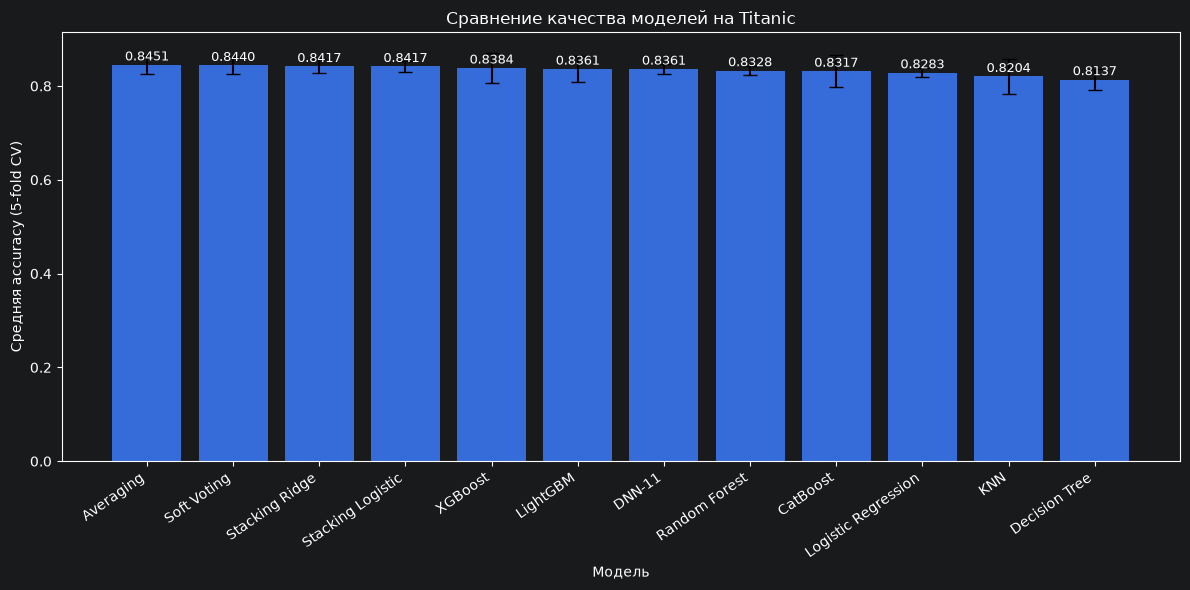

Лучшая модель: Averaging (0.8451)
Худшая модель: Decision Tree (0.8137)


In [132]:
final_results = results.sort_values(
    "accuracy_mean",
    ascending=False
).reset_index(drop=True)

plt.figure(figsize=(12, 6))

bars = plt.bar(
    final_results["model"],
    final_results["accuracy_mean"],
    yerr=final_results["accuracy_std"],
    capsize=5,
)

plt.title("Сравнение качества моделей на Titanic")
plt.xlabel("Модель")
plt.ylabel("Средняя accuracy (5-fold CV)")
plt.xticks(rotation=35, ha="right")

for bar, value in zip(bars, final_results["accuracy_mean"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()
best_model = final_results.iloc[0]
worst_model = final_results.iloc[-1]

print("Лучшая модель:", best_model["model"], f"({best_model['accuracy_mean']:.4f})")
print("Худшая модель:", worst_model["model"], f"({worst_model['accuracy_mean']:.4f})")

## 11. Выживаемость по группам

График показывает фактическую долю выживших, а не причинный эффект или feature importance.

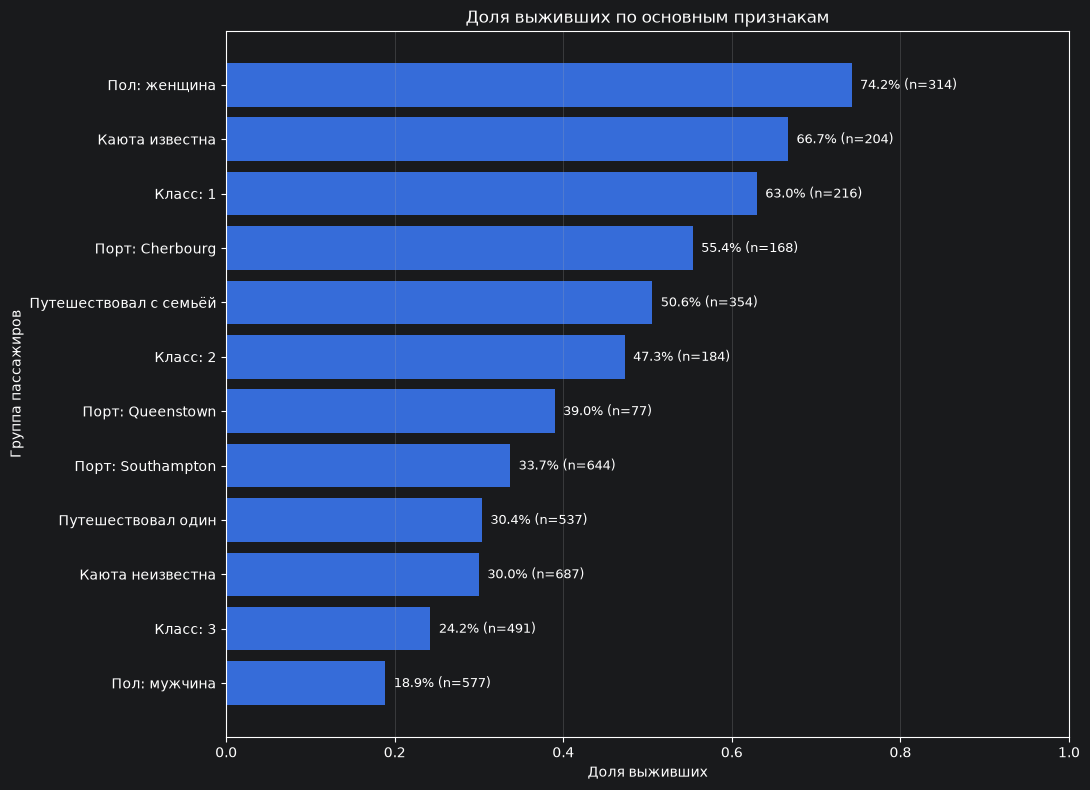

,group,feature,survival_rate,passenger_count
11,Пол: женщина,Sex,0.742,314
10,Каюта известна,CabinKnown,0.667,204
9,Класс: 1,Pclass,0.630,216
8,Порт: Cherbourg,Embarked,0.554,168
7,Путешествовал с семьёй,IsAlone,0.506,354
6,Класс: 2,Pclass,0.473,184
5,Порт: Queenstown,Embarked,0.390,77
4,Порт: Southampton,Embarked,0.337,644
3,Путешествовал один,IsAlone,0.304,537
2,Каюта неизвестна,CabinKnown,0.300,687


In [133]:
feature_labels = {
    "Sex": {
        "female": "Пол: женщина",
        "male": "Пол: мужчина",
    },
    "Pclass": {
        1: "Класс: 1",
        2: "Класс: 2",
        3: "Класс: 3",
    },
    "IsAlone": {
        0: "Путешествовал с семьёй",
        1: "Путешествовал один",
    },
    "CabinKnown": {
        0: "Каюта неизвестна",
        1: "Каюта известна",
    },
    "Embarked": {
        "C": "Порт: Cherbourg",
        "Q": "Порт: Queenstown",
        "S": "Порт: Southampton",
    },
}

survival_groups = []

for feature, labels in feature_labels.items():
    grouped = (
        train_fe
        .groupby(feature, dropna=False)["Survived"]
        .agg(
            survival_rate="mean",
            passenger_count="count",
        )
        .reset_index()
    )

    grouped["group"] = grouped[feature].map(labels)
    grouped["feature"] = feature

    survival_groups.append(
        grouped[
            [
                "group",
                "feature",
                "survival_rate",
                "passenger_count",
            ]
        ]
    )

survival_summary = pd.concat(
    survival_groups,
    ignore_index=True,
)

survival_summary = (
    survival_summary
    .dropna(subset=["group"])
    .sort_values("survival_rate", ascending=True)
    .reset_index(drop=True)
)

plt.figure(figsize=(11, 8))

bars = plt.barh(
    survival_summary["group"],
    survival_summary["survival_rate"],
)

for bar, rate, count in zip(
    bars,
    survival_summary["survival_rate"],
    survival_summary["passenger_count"],
):
    plt.text(
        rate + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.1%} (n={count})",
        va="center",
        fontsize=9,
    )

plt.title("Доля выживших по основным признакам")
plt.xlabel("Доля выживших")
plt.ylabel("Группа пассажиров")
plt.xlim(0, 1)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

display(
    survival_summary
    .sort_values("survival_rate", ascending=False)
    .round({
        "survival_rate": 3,
    })
)

### Почему влияет `CabinKnown`

Это прокси-признак, связанный с классом пассажира, стоимостью билета и расположением каюты.

In [134]:
cabin_by_class = pd.crosstab(
    train_fe["Pclass"],
    train_fe["CabinKnown"],
    normalize="index",
).round(3)

print("Доля пассажиров с известной и неизвестной каютой по классам:")
print(cabin_by_class)

cabin_class_survival = (
    train_fe
    .groupby(["Pclass", "CabinKnown"])["Survived"]
    .agg(
        survival_rate="mean",
        passenger_count="count",
    )
    .reset_index()
)

print(cabin_class_survival.round(3).to_string(index=False))

Доля пассажиров с известной и неизвестной каютой по классам:
CabinKnown      0      1
Pclass                  
1           0.185  0.815
2           0.913  0.087
3           0.976  0.024
 Pclass  CabinKnown  survival_rate  passenger_count
      1           0          0.475               40
      1           1          0.665              176
      2           0          0.440              168
      2           1          0.812               16
      3           0          0.236              479
      3           1          0.500               12


## 12. Итог

- Feature engineering улучшил линейный бейзлайн.
- Ансамбли превзошли большинство одиночных моделей.
- Более крупная DNN не гарантировала улучшения на небольшом табличном датасете.
- Рабочий pipeline вынесен в `src/` и запускается через `main.py`.
